## Pelabelan aplikasi shopeepay

In [1]:
import pandas as pd

data = pd.read_csv("../../Preprocess/PreprocessShopeepay/DatasetPreprocessShopeepay/Tahap4Preprocessing.csv")
print(data.head())

                                         Review text  \
0  Di coba dulu. Kalau memuaskan, bisa diberikan ...   
1                                       mantap murah   
2                                            mantabb   
3                  bisa bayar pulsa dan juga belanja   
4                kenapa pas transaksi gagal mulu min   

                                         clean_text  \
0  coba dulu kalau memuaskan bisa diberikan bintang   
1                                      mantap murah   
2                                           mantabb   
3                     bisa bayar pulsa juga belanja   
4                       kenapa transaksi gagal mulu   

                                   normalisasi_text  \
0  coba dulu kalau memuaskan bisa diberikan bintang   
1                                      mantap murah   
2                                            mantab   
3                     bisa bayar pulsa juga belanja   
4                       kenapa transaksi gagal mulu   

 

In [2]:
# Cek apakah ada missing value di dalam dataset
data.isnull().sum()

Review text         0
clean_text          0
normalisasi_text    0
tokenize            0
stopword_removal    0
steming_data        0
dtype: int64

In [3]:
import pandas as pd
import csv

# Membaca kamus 
positive_path = "../../kamus/positive.tsv"
negative_path = "../../kamus/negative.tsv"

positive_data = pd.read_csv(positive_path, sep='\t', header=None, names=['word', 'score'], skiprows=1, encoding='utf-8')
negative_data = pd.read_csv(negative_path, sep='\t', header=None, names=['word', 'score'], skiprows=1, encoding='utf-8')

# Buat kamus dengan huruf kecil dan tanpa spasi
lexicon_positive = dict(zip(positive_data['word'].str.strip().str.lower(), positive_data['score'].astype(int)))
lexicon_negative = dict(zip(negative_data['word'].str.strip().str.lower(), negative_data['score'].astype(int)))

print(f"Kata positif: {len(lexicon_positive)} | Kata negatif: {len(lexicon_negative)}")

# Logika skoring kata, penentuan polaritas berdasarkan skor
def sentiment_analysis_lexicon(text):
    score = 0
    for word in str(text).lower().split():
        word = word.strip()
        if word in lexicon_positive:
            score += lexicon_positive[word]
        elif word in lexicon_negative:
            score -= abs(lexicon_negative[word])
    
    if score > 0:
        polarity = 'positive'
    elif score < 0:
        polarity = 'negative'
    else:
        polarity = 'neutral'

    return score, polarity

data[['score', 'label']] = data['steming_data'].apply(
    lambda x: pd.Series(sentiment_analysis_lexicon(x))
)

print(data[['steming_data', 'score', 'label']])


Kata positif: 3607 | Kata negatif: 6607


                         steming_data  score     label
0                   coba muas bintang      7  positive
1                        mantap murah      8  positive
2                              mantab      0   neutral
3                 bayar pulsa belanja      0   neutral
4                transaksi gagal mulu      2  positive
...                               ...    ...       ...
8872                  bagus shopeepay      2  positive
8873           gratis transaksi mudah     12  positive
8874  mantap proses cepat pakai ribet      5  positive
8875              alhamdulillah bantu      8  positive
8876                       suka bantu      6  positive

[8877 rows x 3 columns]


In [4]:
import os
folder_tujuan = 'DatasetPelabelanShopeepay' 

if not os.path.exists(folder_tujuan):
    os.makedirs(folder_tujuan)

path_output = os.path.join(folder_tujuan, 'Tahap5HasilPelabelan.csv')
data.to_csv(path_output, index=False, encoding='utf-8')
print(f"File berhasil disimpan di: {path_output}")
data.info()

File berhasil disimpan di: DatasetPelabelanShopeepay\Tahap5HasilPelabelan.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8877 entries, 0 to 8876
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Review text       8877 non-null   object
 1   clean_text        8877 non-null   object
 2   normalisasi_text  8877 non-null   object
 3   tokenize          8877 non-null   object
 4   stopword_removal  8877 non-null   object
 5   steming_data      8877 non-null   object
 6   score             8877 non-null   int64 
 7   label             8877 non-null   object
dtypes: int64(1), object(7)
memory usage: 554.9+ KB


## Pemodelan tanpa smote

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- 1. LOAD DATASET ---
file_path = "../../Pelabelan/PelabelanShopeepay/DatasetPelabelanShopeepay\Tahap5HasilPelabelan.csv"

try:
    data = pd.read_csv(file_path)
    print(f"[SUKSES] Data berhasil dimuat dari: {file_path}")
except FileNotFoundError:
    print(f"[ERROR] File tidak ditemukan di: {file_path}")
    print("Pastikan path file sudah benar.")
    exit() # Hentikan program jika file tidak ada

# --- 2. PERSIAPAN DATA (DATA PREPARATION) ---

# Pastikan kolom target ada
if 'steming_data' not in data.columns or 'Label' not in data.columns:
    print("[ERROR] Kolom 'steming_data' atau 'Label' tidak ditemukan.")
    print(f"Kolom yang tersedia: {list(data.columns)}")
    exit()

print(f"Jumlah data awal: {len(data)}")

# Konversi ke string (jaga-jaga jika ada angka) dan drop NaN
data['steming_data'] = data['steming_data'].astype(str)
data.dropna(subset=['steming_data', 'label'], inplace=True)

# Hapus data yang isinya hanya spasi kosong atau string kosong
data = data[data['steming_data'].str.strip() != '']
data = data[data['steming_data'] != 'nan'] # Hapus string "nan" literal jika ada

print(f"Jumlah data bersih: {len(data)}")

# Cek sebaran data (Penting untuk melihat imbalance)
print("\nSebaran Data per Label:")
print(data['label'].value_counts())

X_text = data['steming_data']
y = data['label']

# --- 3. EKSTRAKSI FITUR (TF-IDF) ---
print("\nMelakukan ekstraksi fitur TF-IDF...")
# max_features=5000 mengambil 5000 kata teratas berdasarkan frekuensi
tfidf = TfidfVectorizer(max_features=5000) 
X = tfidf.fit_transform(X_text)

print(f"Ukuran Matriks TF-IDF: {X.shape}") 

# --- 4. SPLIT DATA ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 5. PELATIHAN MODEL SVM ---
print("\nMelatih Model SVM...")

# PERBAIKAN: Tambahkan class_weight='balanced'
# Ini membantu jika jumlah data Positif jauh lebih banyak dari Negatif/Netral
svm_model = SVC(kernel='linear', class_weight='balanced', random_state=42) 
svm_model.fit(X_train, y_train)

print("Pelatihan selesai!")

# --- 6. EVALUASI MODEL ---
y_pred = svm_model.predict(X_test)
akurasi = accuracy_score(y_test, y_pred)

print(f"\n--- HASIL EVALUASI ---")
print(f"Akurasi Model: {akurasi * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


[SUKSES] Data berhasil dimuat dari: ../../Pelabelan/PelabelanShopeepay/DatasetPelabelanShopeepay\Tahap5HasilPelabelan.csv
[ERROR] Kolom 'steming_data' atau 'Label' tidak ditemukan.
Kolom yang tersedia: ['Review text', 'clean_text', 'normalisasi_text', 'tokenize', 'stopword_removal', 'steming_data', 'score', 'label']
Jumlah data awal: 8877
Jumlah data bersih: 8877

Sebaran Data per Label:
label
positive    6150
negative    1445
neutral     1282
Name: count, dtype: int64

Melakukan ekstraksi fitur TF-IDF...
Ukuran Matriks TF-IDF: (8877, 5000)

Melatih Model SVM...
Pelatihan selesai!

--- HASIL EVALUASI ---
Akurasi Model: 90.32%

Classification Report:
              precision    recall  f1-score   support

    negative       0.79      0.86      0.83       288
     neutral       0.70      0.93      0.80       240
    positive       0.99      0.91      0.95      1248

    accuracy                           0.90      1776
   macro avg       0.83      0.90      0.86      1776
weighted avg    

: 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB  # <--- IMPORT BARU
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- 1. LOAD DATASET ---
# Note: Python string path sebaiknya raw string (r"...") atau forward slash (/) semua
file_path = "../../Pelabelan/PelabelanShopeepay/DatasetPelabelanShopeepay/Tahap5HasilPelabelan.csv"

try:
    data = pd.read_csv(file_path)
    print(f"[SUKSES] Data berhasil dimuat dari: {file_path}")
except FileNotFoundError:
    print(f"[ERROR] File tidak ditemukan di: {file_path}")
    exit()

# --- 2. PERSIAPAN DATA (DATA PREPARATION) ---

# Perbaiki pengecekan kolom (gunakan 'label' huruf kecil sesuai error sebelumnya)
if 'steming_data' not in data.columns or 'label' not in data.columns:
    print("[ERROR] Kolom 'steming_data' atau 'label' tidak ditemukan.")
    print(f"Kolom yang tersedia: {list(data.columns)}")
    exit()

print(f"Jumlah data awal: {len(data)}")

# Konversi ke string & Bersihkan NaN
data['steming_data'] = data['steming_data'].astype(str)
data.dropna(subset=['steming_data', 'label'], inplace=True)

# Hapus data kosong/spasi saja
data = data[data['steming_data'].str.strip() != '']
data = data[data['steming_data'] != 'nan']

print(f"Jumlah data bersih: {len(data)}")

# Cek sebaran data
print("\nSebaran Data per Label:")
print(data['label'].value_counts())

X_text = data['steming_data']
y = data['label']

# --- 3. EKSTRAKSI FITUR (TF-IDF) ---
print("\nMelakukan ekstraksi fitur TF-IDF...")
tfidf = TfidfVectorizer(max_features=5000) 
X = tfidf.fit_transform(X_text)

print(f"Ukuran Matriks TF-IDF: {X.shape}") 

# --- 4. SPLIT DATA ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 5. PELATIHAN MODEL NAIVE BAYES ---
print("\nMelatih Model Naive Bayes (MultinomialNB)...")

# GANTI SVM DENGAN NAIVE BAYES DI SINI
nb_model = MultinomialNB() 
nb_model.fit(X_train, y_train)

print("Pelatihan selesai!")

# --- 6. EVALUASI MODEL ---
y_pred = nb_model.predict(X_test)
akurasi = accuracy_score(y_test, y_pred)

print(f"\n--- HASIL EVALUASI NAIVE BAYES ---")
print(f"Akurasi Model: {akurasi * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

[SUKSES] Data berhasil dimuat dari: ../../Pelabelan/PelabelanShopeepay/DatasetPelabelanShopeepay/Tahap5HasilPelabelan.csv
Jumlah data awal: 8877
Jumlah data bersih: 8877

Sebaran Data per Label:
label
positive    6150
negative    1445
neutral     1282
Name: count, dtype: int64

Melakukan ekstraksi fitur TF-IDF...
Ukuran Matriks TF-IDF: (8877, 5000)

Melatih Model Naive Bayes (MultinomialNB)...
Pelatihan selesai!

--- HASIL EVALUASI NAIVE BAYES ---
Akurasi Model: 74.44%

Classification Report:
              precision    recall  f1-score   support

    negative       0.97      0.23      0.37       288
     neutral       0.92      0.05      0.09       240
    positive       0.73      1.00      0.85      1248

    accuracy                           0.74      1776
   macro avg       0.88      0.42      0.44      1776
weighted avg       0.80      0.74      0.67      1776



## Pemodelan dengan smote

[SUKSES] Data berhasil dimuat dari: ../../Pelabelan/PelabelanShopeepay/DatasetPelabelanShopeepay/Tahap5HasilPelabelan.csv
Jumlah data awal: 8877
Jumlah data bersih: 8877

Sebaran Data Asli:
label
positive    6150
negative    1445
neutral     1282
Name: count, dtype: int64

Melakukan ekstraksi fitur TF-IDF...

Data Training Asli: 7101
Data Testing: 1776

Menerapkan SMOTE pada data training...
Data Training setelah SMOTE: 14706
Sebaran Data Training Baru (Seimbang):
label
positive    4902
neutral     4902
negative    4902
Name: count, dtype: int64

Melatih Model SVM dengan data hasil SMOTE...
Pelatihan selesai!

--- HASIL EVALUASI (SVM + SMOTE - ShopeePay) ---
Akurasi Model: 91.05%

Classification Report:
              precision    recall  f1-score   support

    negative       0.83      0.84      0.83       288
     neutral       0.71      0.92      0.80       240
    positive       0.99      0.93      0.95      1248

    accuracy                           0.91      1776
   macro avg   

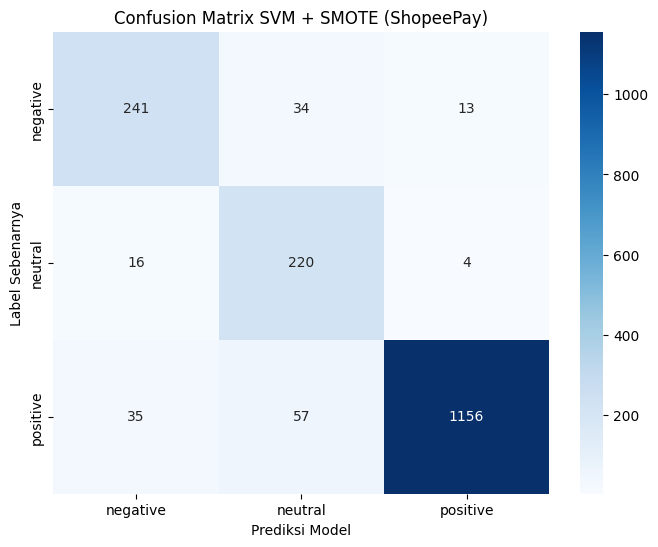

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# --- 1. IMPORT SMOTE ---
from imblearn.over_sampling import SMOTE

# --- 2. LOAD DATASET ---
# Menggunakan forward slash (/) agar aman di Windows/Linux
file_path = "../../Pelabelan/PelabelanShopeepay/DatasetPelabelanShopeepay/Tahap5HasilPelabelan.csv"

try:
    data = pd.read_csv(file_path)
    print(f"[SUKSES] Data berhasil dimuat dari: {file_path}")
except FileNotFoundError:
    print(f"[ERROR] File tidak ditemukan di: {file_path}")
    print("Pastikan path file sudah benar.")
    exit()

# --- 3. PERSIAPAN DATA ---

# Perbaiki konsistensi nama kolom (gunakan 'label' kecil)
if 'steming_data' not in data.columns or 'label' not in data.columns:
    print("[ERROR] Kolom 'steming_data' atau 'label' tidak ditemukan.")
    print(f"Kolom yang tersedia: {list(data.columns)}")
    exit()

print(f"Jumlah data awal: {len(data)}")

# Konversi ke string & Bersihkan NaN
data['steming_data'] = data['steming_data'].astype(str)
data.dropna(subset=['steming_data', 'label'], inplace=True)

# Hapus data kosong
data = data[data['steming_data'].str.strip() != '']
data = data[data['steming_data'] != 'nan']

print(f"Jumlah data bersih: {len(data)}")

# Cek sebaran data SEBELUM SMOTE
print("\nSebaran Data Asli:")
print(data['label'].value_counts())

X_text = data['steming_data']
y = data['label']

# --- 4. EKSTRAKSI FITUR (TF-IDF) ---
print("\nMelakukan ekstraksi fitur TF-IDF...")
tfidf = TfidfVectorizer(max_features=5000) 
X = tfidf.fit_transform(X_text)

# --- 5. SPLIT DATA ---
# Pisahkan Data Latih (Train) dan Uji (Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nData Training Asli: {X_train.shape[0]}")
print(f"Data Testing: {X_test.shape[0]}")

# --- 6. PENERAPAN SMOTE (HANYA PADA DATA LATIH) ---
print("\nMenerapkan SMOTE pada data training...")
# SMOTE akan membuat jumlah data Netral/Negatif sama banyaknya dengan Positif
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Cek hasil setelah SMOTE
print(f"Data Training setelah SMOTE: {X_train_resampled.shape[0]}")
print("Sebaran Data Training Baru (Seimbang):")
print(pd.Series(y_train_resampled).value_counts())

# --- 7. PELATIHAN MODEL SVM ---
print("\nMelatih Model SVM dengan data hasil SMOTE...")

# CATATAN: Karena data sudah seimbang berkat SMOTE, 
# kita hapus class_weight='balanced' agar melihat performa murni SMOTE.
svm_model = SVC(kernel='linear', random_state=42) 
svm_model.fit(X_train_resampled, y_train_resampled)

print("Pelatihan selesai!")

# --- 8. EVALUASI MODEL ---
# Prediksi tetap dilakukan ke data X_test yang ASLI (Murni, bukan hasil SMOTE)
y_pred = svm_model.predict(X_test)
akurasi = accuracy_score(y_test, y_pred)

print(f"\n--- HASIL EVALUASI (SVM + SMOTE - ShopeePay) ---")
print(f"Akurasi Model: {akurasi * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# --- 9. VISUALISASI ---
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=svm_model.classes_, 
            yticklabels=svm_model.classes_)
plt.title('Confusion Matrix SVM + SMOTE (ShopeePay)')
plt.ylabel('Label Sebenarnya')
plt.xlabel('Prediksi Model')
plt.show()

[SUKSES] Data berhasil dimuat dari: ../../Pelabelan/PelabelanShopeepay/DatasetPelabelanShopeepay/Tahap5HasilPelabelan.csv
Jumlah data awal: 8877
Jumlah data bersih: 8877

Sebaran Data Asli:
label
positive    6150
negative    1445
neutral     1282
Name: count, dtype: int64

Melakukan ekstraksi fitur TF-IDF...

Data Training Asli: 7101
Data Testing: 1776

Menerapkan SMOTE pada data training...
Data Training setelah SMOTE: 14706
Sebaran Data Training Baru (Seimbang):
label
positive    4902
neutral     4902
negative    4902
Name: count, dtype: int64

Melatih Model Naive Bayes dengan data SMOTE...
Pelatihan selesai!

--- HASIL EVALUASI (Naive Bayes + SMOTE - ShopeePay) ---
Akurasi Model: 83.56%

Classification Report:
              precision    recall  f1-score   support

    negative       0.61      0.86      0.71       288
     neutral       0.68      0.67      0.67       240
    positive       0.95      0.86      0.90      1248

    accuracy                           0.84      1776
   ma

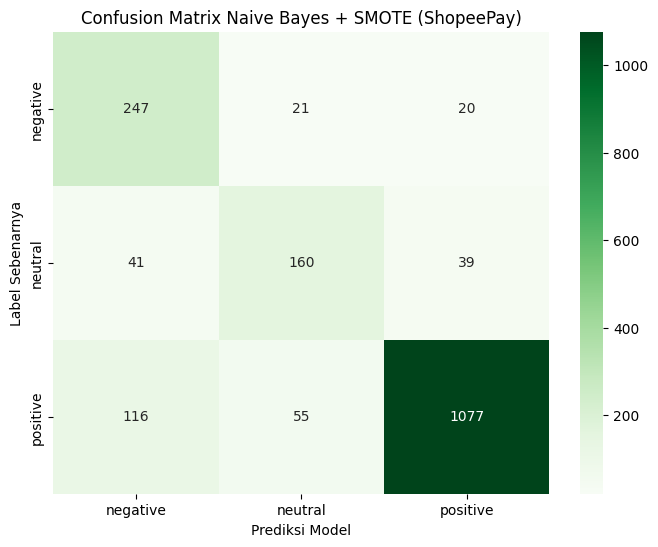

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# --- 1. IMPORT SMOTE ---
from imblearn.over_sampling import SMOTE

# --- 2. LOAD DATASET ---
file_path = "../../Pelabelan/PelabelanShopeepay/DatasetPelabelanShopeepay/Tahap5HasilPelabelan.csv"

try:
    data = pd.read_csv(file_path)
    print(f"[SUKSES] Data berhasil dimuat dari: {file_path}")
except FileNotFoundError:
    print(f"[ERROR] File tidak ditemukan di: {file_path}")
    print("Pastikan path file sudah benar.")
    exit()

# --- 3. PERSIAPAN DATA ---

# Pengecekan kolom
if 'steming_data' not in data.columns or 'label' not in data.columns:
    print("[ERROR] Kolom 'steming_data' atau 'label' tidak ditemukan.")
    exit()

print(f"Jumlah data awal: {len(data)}")

# Konversi ke string & Bersihkan NaN
data['steming_data'] = data['steming_data'].astype(str)
data.dropna(subset=['steming_data', 'label'], inplace=True)
data = data[data['steming_data'].str.strip() != '']
data = data[data['steming_data'] != 'nan']

print(f"Jumlah data bersih: {len(data)}")

# Cek sebaran data SEBELUM SMOTE
print("\nSebaran Data Asli:")
print(data['label'].value_counts())

X_text = data['steming_data']
y = data['label']

# --- 4. EKSTRAKSI FITUR (TF-IDF) ---
print("\nMelakukan ekstraksi fitur TF-IDF...")
tfidf = TfidfVectorizer(max_features=5000) 
X = tfidf.fit_transform(X_text)

# --- 5. SPLIT DATA ---
# Pisahkan Data Latih (Train) dan Uji (Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nData Training Asli: {X_train.shape[0]}")
print(f"Data Testing: {X_test.shape[0]}")

# --- 6. PENERAPAN SMOTE (HANYA PADA DATA LATIH) ---
print("\nMenerapkan SMOTE pada data training...")

# Inisialisasi SMOTE
smote = SMOTE(random_state=42)

# Lakukan resampling hanya pada X_train dan y_train
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Cek hasil setelah SMOTE
print(f"Data Training setelah SMOTE: {X_train_resampled.shape[0]}")
print("Sebaran Data Training Baru (Seimbang):")
print(pd.Series(y_train_resampled).value_counts())

# --- 7. PELATIHAN MODEL NAIVE BAYES ---
print("\nMelatih Model Naive Bayes dengan data SMOTE...")

# Inisialisasi MultinomialNB
nb_model = MultinomialNB() 

# Latih model menggunakan data yang SUDAH di-resample (Seimbang)
nb_model.fit(X_train_resampled, y_train_resampled)

print("Pelatihan selesai!")

# --- 8. EVALUASI MODEL ---
# Prediksi dilakukan ke data X_test yang ASLI (Murni)
y_pred = nb_model.predict(X_test)
akurasi = accuracy_score(y_test, y_pred)

print(f"\n--- HASIL EVALUASI (Naive Bayes + SMOTE - ShopeePay) ---")
print(f"Akurasi Model: {akurasi * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# --- 9. VISUALISASI CONFUSION MATRIX ---
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
# Menggunakan warna hijau (Greens) khas Naive Bayes
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=nb_model.classes_, 
            yticklabels=nb_model.classes_)
plt.title('Confusion Matrix Naive Bayes + SMOTE (ShopeePay)')
plt.ylabel('Label Sebenarnya')
plt.xlabel('Prediksi Model')
plt.show()